In [1]:
!pip install torch torchvision torchaudio
!pip install matplotlib numpy pillow tqdm


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import os
from tqdm import tqdm
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt





In [4]:
path = r"E:\Group_52\Image\v2\data"


print("\nTop-level contents:")
print(os.listdir(path))




Top-level contents:
['colorgram', 'train', 'val']


In [5]:
class Sketch2ColorDataset(Dataset):
    def __init__(self, folder, img_size=128):
        self.folder = folder
        self.files = sorted(os.listdir(folder))
        self.img_size = img_size

        # Transform for sketch (1 channel)
        self.transform_sketch = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # [-1,1]
        ])

        # Transform for color image (3 channels)
        self.transform_color = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])  # [-1,1]
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
      path = os.path.join(self.folder, self.files[idx])
      img = Image.open(path).convert("RGB")
      w, h = img.size

      # LEFT = color, RIGHT = sketch
      color  = img.crop((0, 0, w//2, h))
      sketch = img.crop((w//2, 0, w, h)).convert("L")  # convert to grayscale

      sketch = self.transform_sketch(sketch)  # shape [1,H,W]
      color  = self.transform_color(color)    # shape [3,H,W]

      return sketch, color, self.files[idx]


Device: cpu


Epoch [1/20]: 100%|██████████| 1778/1778 [14:04<00:00,  2.10it/s]


Epoch 001 | G: 12.065 | D: 0.308 | Val L1: 0.3118
✅ Saved best model.


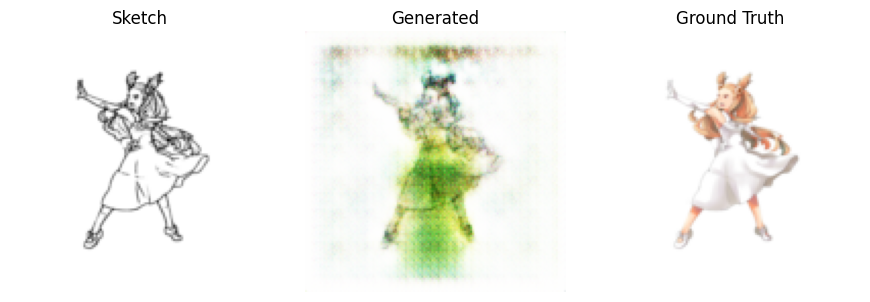

Epoch [2/20]: 100%|██████████| 1778/1778 [11:55<00:00,  2.48it/s]


Epoch 002 | G: 11.825 | D: 0.252 | Val L1: 0.2660
✅ Saved best model.


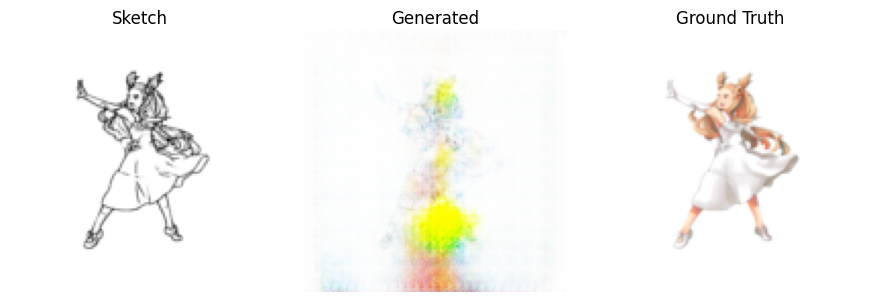

Epoch [3/20]: 100%|██████████| 1778/1778 [12:08<00:00,  2.44it/s]


Epoch 003 | G: 11.419 | D: 0.257 | Val L1: 0.2350
✅ Saved best model.


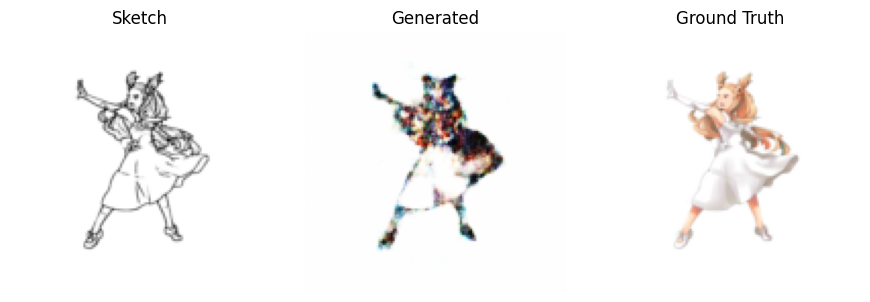

Epoch [4/20]: 100%|██████████| 1778/1778 [12:23<00:00,  2.39it/s]


Epoch 004 | G: 11.124 | D: 0.263 | Val L1: 0.2108
✅ Saved best model.


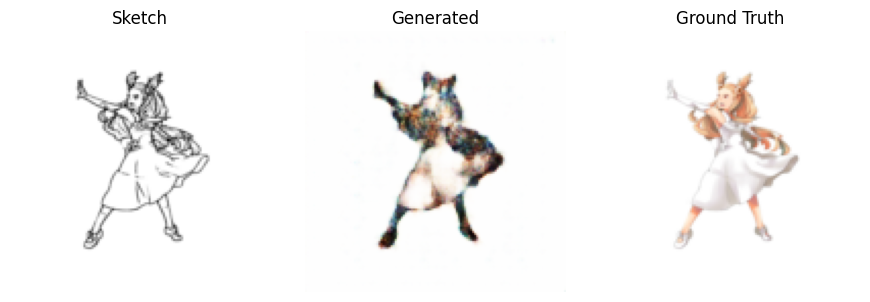

Epoch [5/20]: 100%|██████████| 1778/1778 [12:24<00:00,  2.39it/s]


Epoch 005 | G: 11.002 | D: 0.257 | Val L1: 0.2300


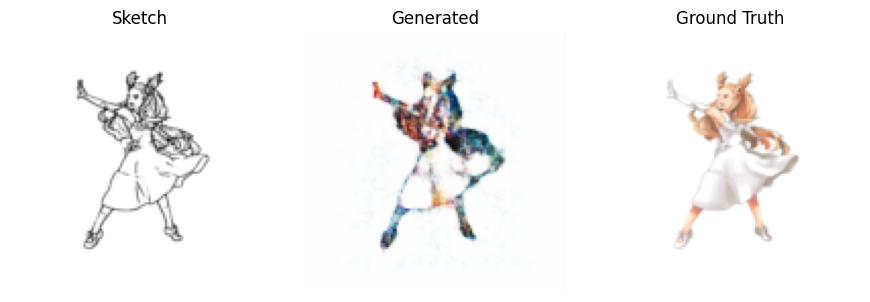

Epoch [6/20]: 100%|██████████| 1778/1778 [12:21<00:00,  2.40it/s]


Epoch 006 | G: 10.989 | D: 0.254 | Val L1: 0.1974
✅ Saved best model.


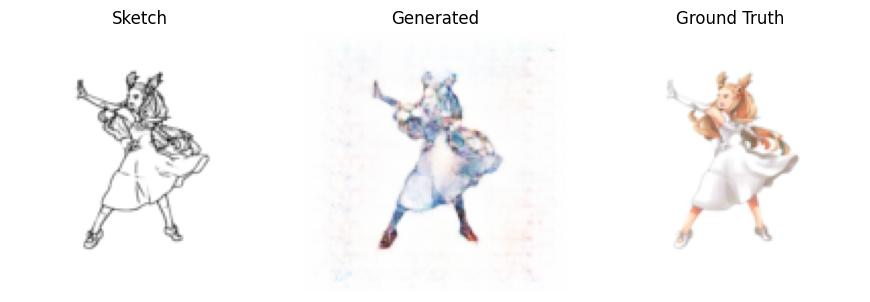

Epoch [7/20]: 100%|██████████| 1778/1778 [12:10<00:00,  2.43it/s]


Epoch 007 | G: 10.886 | D: 0.251 | Val L1: 0.1889
✅ Saved best model.


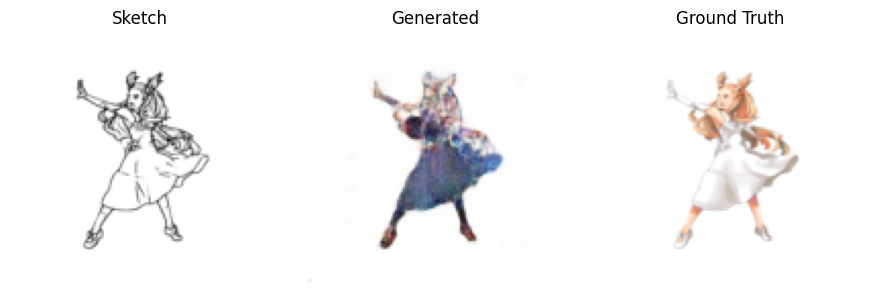

Epoch [8/20]: 100%|██████████| 1778/1778 [12:20<00:00,  2.40it/s]


Epoch 008 | G: 10.687 | D: 0.265 | Val L1: 0.2244


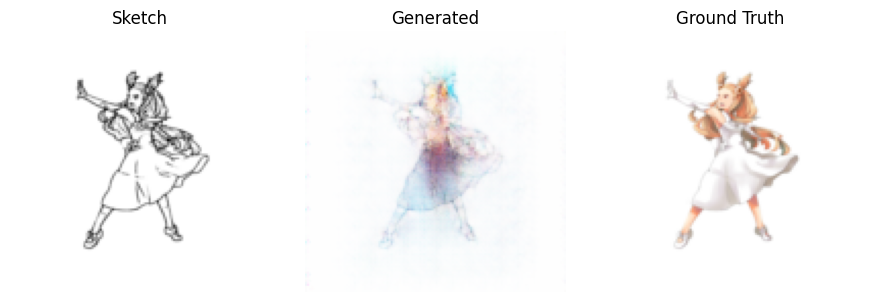

Epoch [9/20]: 100%|██████████| 1778/1778 [11:44<00:00,  2.52it/s]


Epoch 009 | G: 10.484 | D: 0.259 | Val L1: 0.2839


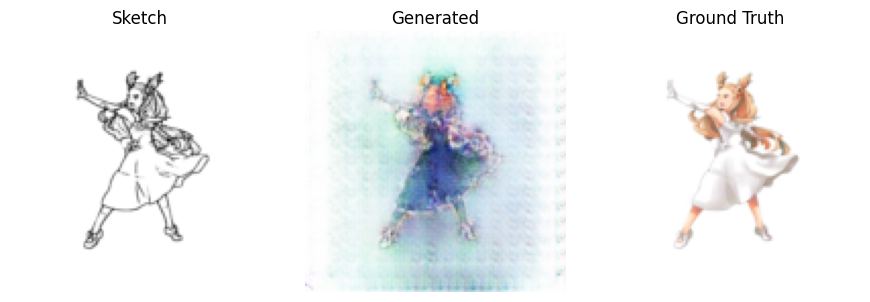

Epoch [10/20]: 100%|██████████| 1778/1778 [11:49<00:00,  2.51it/s]


Epoch 010 | G: 10.331 | D: 0.264 | Val L1: 0.2310


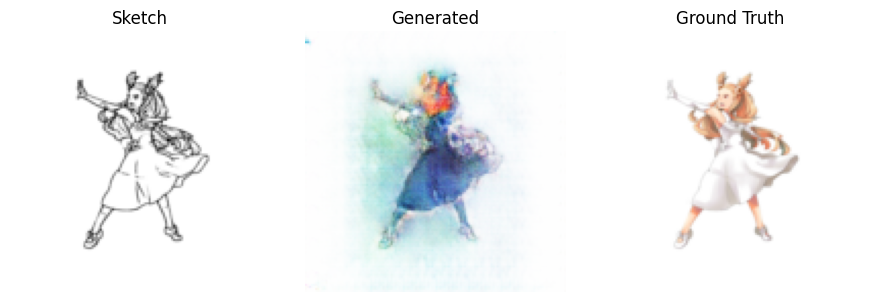

Epoch [11/20]: 100%|██████████| 1778/1778 [11:53<00:00,  2.49it/s]


Epoch 011 | G: 10.214 | D: 0.280 | Val L1: 0.2468


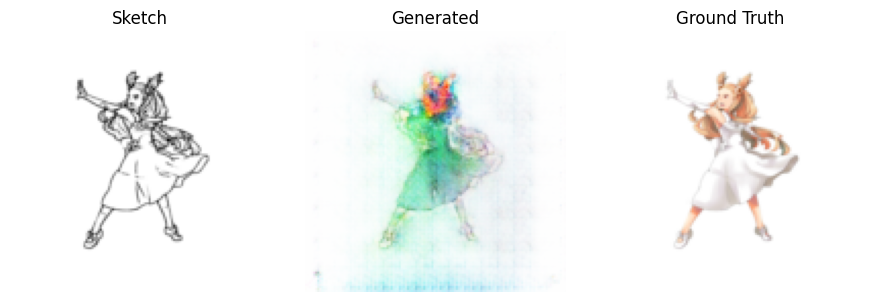

Epoch [12/20]: 100%|██████████| 1778/1778 [12:06<00:00,  2.45it/s]


Epoch 012 | G: 10.139 | D: 0.272 | Val L1: 0.2025


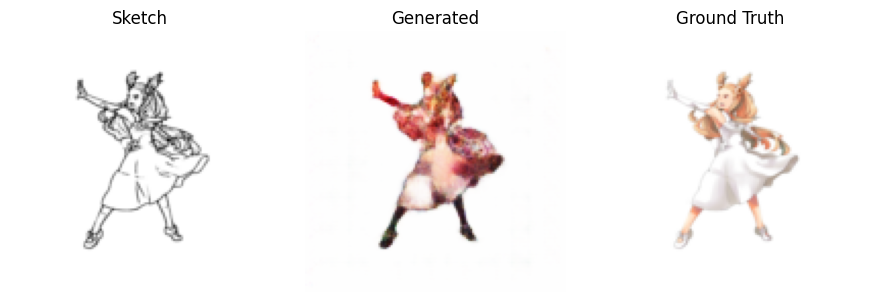

Epoch [13/20]: 100%|██████████| 1778/1778 [12:04<00:00,  2.45it/s]


Epoch 013 | G: 9.930 | D: 0.285 | Val L1: 0.2142


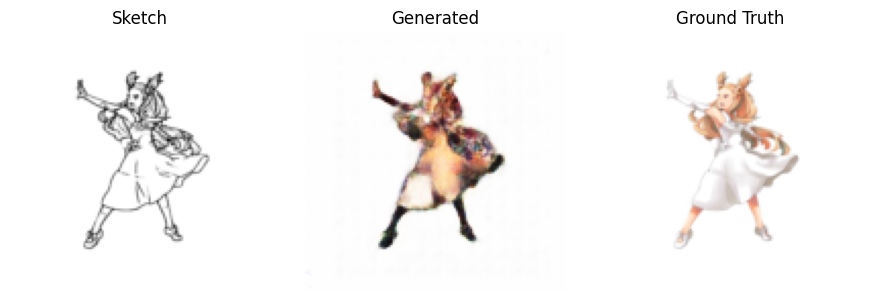

Epoch [14/20]: 100%|██████████| 1778/1778 [12:04<00:00,  2.45it/s]


Epoch 014 | G: 9.730 | D: 0.298 | Val L1: 0.1784
✅ Saved best model.


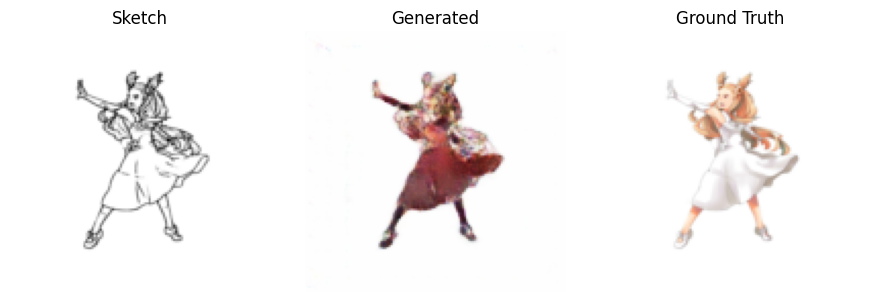

Epoch [15/20]: 100%|██████████| 1778/1778 [12:10<00:00,  2.43it/s]


Epoch 015 | G: 9.862 | D: 0.275 | Val L1: 0.2161


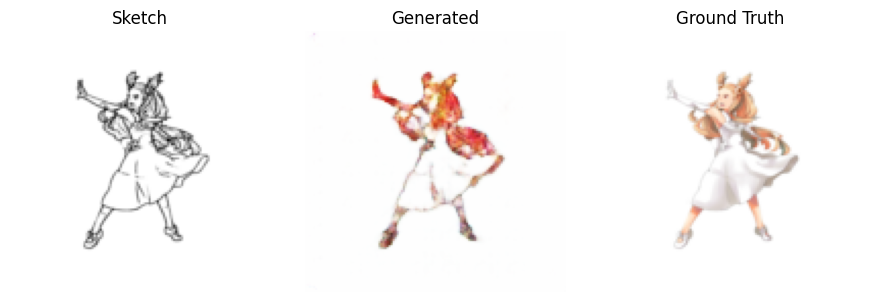

Epoch [16/20]: 100%|██████████| 1778/1778 [12:26<00:00,  2.38it/s]


Epoch 016 | G: 9.696 | D: 0.294 | Val L1: 0.1911


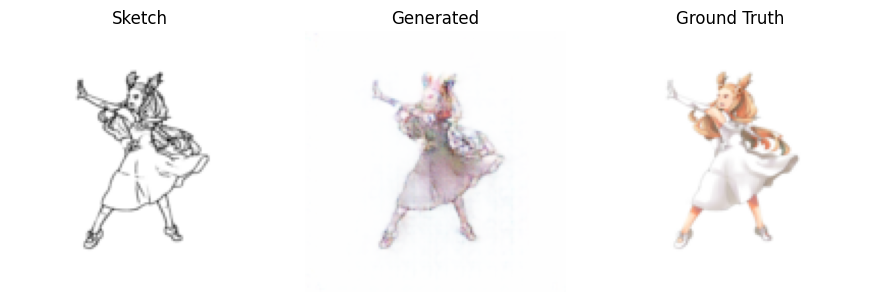

Epoch [17/20]: 100%|██████████| 1778/1778 [12:26<00:00,  2.38it/s]


Epoch 017 | G: 9.657 | D: 0.287 | Val L1: 0.2230


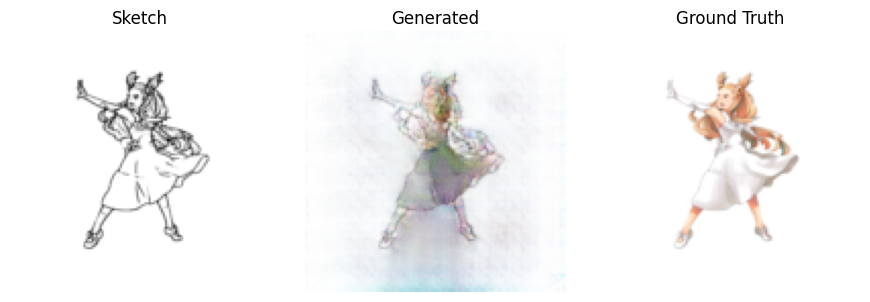

Epoch [18/20]: 100%|██████████| 1778/1778 [12:07<00:00,  2.45it/s]


Epoch 018 | G: 9.515 | D: 0.288 | Val L1: 0.1881


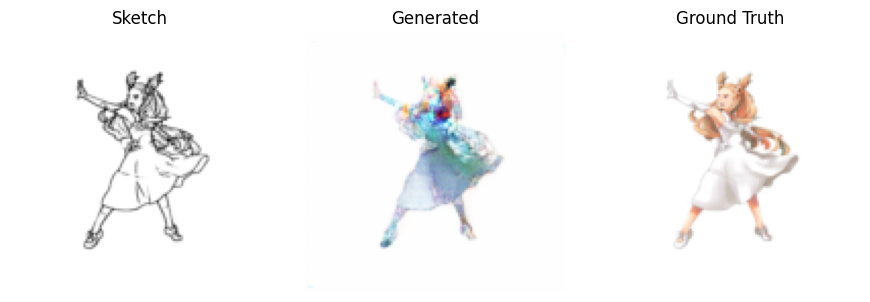

Epoch [19/20]: 100%|██████████| 1778/1778 [12:02<00:00,  2.46it/s]


Epoch 019 | G: 9.619 | D: 0.279 | Val L1: 0.1759
✅ Saved best model.


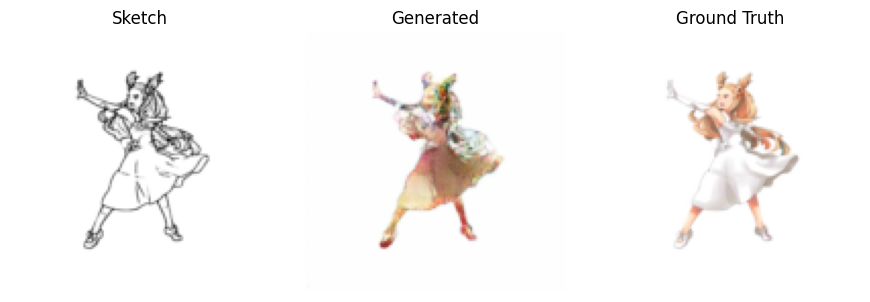

Epoch [20/20]: 100%|██████████| 1778/1778 [12:07<00:00,  2.44it/s]


Epoch 020 | G: 9.491 | D: 0.287 | Val L1: 0.2073


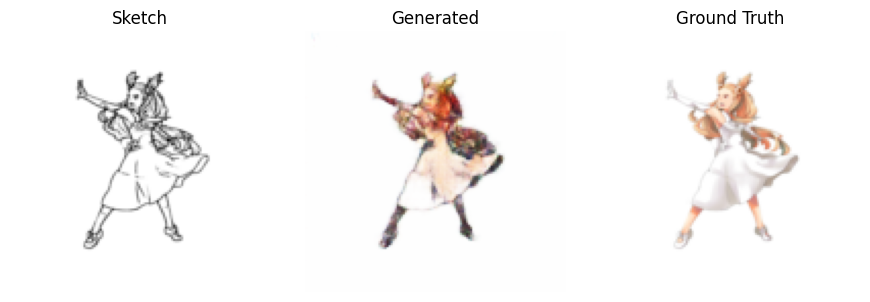

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ============================
# DATASET
# ============================
class Sketch2ColorDataset(Dataset):
    def __init__(self, folder, img_size=128):
        self.folder = folder
        self.files = sorted(os.listdir(folder))
        self.img_size = img_size
        self.t_sketch = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        self.t_color = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.folder, self.files[idx])
        img = Image.open(path).convert("RGB")
        w, h = img.size
        color = img.crop((0, 0, w//2, h))
        sketch = img.crop((w//2, 0, w, h)).convert("L")
        return self.t_sketch(sketch), self.t_color(color), self.files[idx]


# ============================
# GENERATOR (Pix2Pix UNet)
# ============================
class UNetBlock(nn.Module):
    def __init__(self, in_c, out_c, down=True, act="relu", dropout=False):
        super().__init__()
        if down:
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False),
                      nn.BatchNorm2d(out_c)]
        else:
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
                      nn.BatchNorm2d(out_c)]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
        self.act = nn.LeakyReLU(0.2, inplace=True) if act == "leaky" else nn.ReLU(inplace=True)
        self.down = down

    def forward(self, x):
        return self.act(self.block(x))

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3):
        super().__init__()
        self.down1 = nn.Conv2d(in_channels, 64, 4, 2, 1)
        self.down2 = UNetBlock(64, 128, down=True, act="leaky")
        self.down3 = UNetBlock(128, 256, down=True, act="leaky")
        self.down4 = UNetBlock(256, 512, down=True, act="leaky", dropout=True)
        self.down5 = UNetBlock(512, 512, down=True, act="leaky", dropout=True)
        self.down6 = UNetBlock(512, 512, down=True, act="leaky", dropout=True)

        self.up1 = UNetBlock(512, 512, down=False, dropout=True)
        self.up2 = UNetBlock(1024, 512, down=False, dropout=True)
        self.up3 = UNetBlock(1024, 256, down=False)
        self.up4 = UNetBlock(512, 128, down=False)
        self.up5 = UNetBlock(256, 64, down=False)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        u1 = self.up1(d6)
        u2 = self.up2(torch.cat([u1, d5], dim=1))
        u3 = self.up3(torch.cat([u2, d4], dim=1))
        u4 = self.up4(torch.cat([u3, d3], dim=1))
        u5 = self.up5(torch.cat([u4, d2], dim=1))
        return self.final(torch.cat([u5, d1], dim=1))


# ============================
# DISCRIMINATOR
# ============================
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, sketch, color):
        return self.model(torch.cat([sketch, color], dim=1))


# ============================
# TRAINING SETUP
# ============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_folder = r"E:\Group_52\Image\v2\data\train"
val_folder = r"E:\Group_52\Image\v2\data\val"

train_loader = DataLoader(Sketch2ColorDataset(train_folder), batch_size=8, shuffle=True)
val_loader = DataLoader(Sketch2ColorDataset(val_folder), batch_size=1, shuffle=False)

gen = UNetGenerator().to(device)
disc = PatchDiscriminator().to(device)

g_opt = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.999))
d_opt = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion = nn.L1Loss()
lambda_L1 = 40.0

os.makedirs("checkpoints", exist_ok=True)
best_val_loss = float("inf")
patience, counter = 10, 0
EPOCHS = 20


# ============================
# TRAINING LOOP
# ============================
for epoch in range(EPOCHS):
    gen.train(); disc.train()
    g_loss_sum, d_loss_sum = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for sketches, colors, _ in loop:
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)

        # Label smoothing
        real_labels = torch.rand_like(disc(sketches, colors)) * 0.1 + 0.9
        fake_labels = torch.zeros_like(real_labels)

        # --- Train D ---
        d_real = disc(sketches, colors)
        d_fake = disc(sketches, fake_colors.detach())
        d_loss = (adv_criterion(d_real, real_labels) + adv_criterion(d_fake, fake_labels)) / 2

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # --- Train G ---
        g_fake = disc(sketches, fake_colors)
        g_loss_adv = adv_criterion(g_fake, torch.ones_like(g_fake))
        g_loss_l1 = l1_criterion(fake_colors, colors) * lambda_L1
        g_loss = g_loss_adv + g_loss_l1

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        g_loss_sum += g_loss.item()
        d_loss_sum += d_loss.item()

    # =======================
    # VALIDATION
    # =======================
    gen.eval()
    val_l1 = 0.0
    with torch.no_grad():
        for sketches, colors, _ in val_loader:
            sketches, colors = sketches.to(device), colors.to(device)
            out = gen(sketches)
            val_l1 += l1_criterion(out, colors).item()
    val_l1 /= len(val_loader)

    avg_g, avg_d = g_loss_sum / len(train_loader), d_loss_sum / len(train_loader)
    print(f"Epoch {epoch+1:03d} | G: {avg_g:.3f} | D: {avg_d:.3f} | Val L1: {val_l1:.4f}")

    # --- Checkpoints ---
    torch.save(gen.state_dict(), f"checkpoints/gen_latest.pth")
    torch.save(disc.state_dict(), f"checkpoints/disc_latest.pth")
    if val_l1 < best_val_loss:
        best_val_loss = val_l1
        counter = 0
        torch.save(gen.state_dict(), f"checkpoints/gen_best.pth")
        torch.save(disc.state_dict(), f"checkpoints/disc_best.pth")
        print("✅ Saved best model.")
    else:
        counter += 1
        if counter >= patience:
            print("⏹ Early stopping triggered.")
            break

    # --- Visualize sample ---
    with torch.no_grad():
        sketches, colors, _ = next(iter(val_loader))
        sketches = sketches.to(device)
        fake = gen(sketches).cpu()
        fig, axs = plt.subplots(1, 3, figsize=(9, 3))
        axs[0].imshow(((sketches[0][0].cpu() + 1)/2).clamp(0,1), cmap="gray"); axs[0].set_title("Sketch"); axs[0].axis("off")
        axs[1].imshow(((fake[0].permute(1,2,0)+1)/2).clamp(0,1)); axs[1].set_title("Generated"); axs[1].axis("off")
        axs[2].imshow(((colors[0].permute(1,2,0).cpu()+1)/2).clamp(0,1)); axs[2].set_title("Ground Truth"); axs[2].axis("off")
        plt.tight_layout(); plt.show()


In [7]:
torch.save(gen.state_dict(), "generator_final.pth")
torch.save(disc.state_dict(), "discriminator_final.pth")
print("✅ Final models saved.")


✅ Final models saved.


In [9]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np

gen.eval()
ssim_scores, psnr_scores, l1_scores = [], [], []

with torch.no_grad():
    for sketches, colors, _ in tqdm(val_loader, desc="Evaluating"):
        sketches, colors = sketches.to(device), colors.to(device)
        fake = gen(sketches)
        
        # Convert to [0,1] range
        fake_np = ((fake[0].permute(1,2,0).cpu().numpy() + 1) / 2).clip(0,1)
        real_np = ((colors[0].permute(1,2,0).cpu().numpy() + 1) / 2).clip(0,1)

        ssim_scores.append(ssim(fake_np, real_np, channel_axis=2, data_range=1.0))
        psnr_scores.append(psnr(real_np, fake_np, data_range=1.0))

        l1_scores.append(F.l1_loss(fake, colors).item())

print(f"📊 Avg SSIM: {np.mean(ssim_scores):.4f}")
print(f"📊 Avg PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"📊 Avg L1: {np.mean(l1_scores):.4f}")


Evaluating: 100%|██████████| 3545/3545 [01:55<00:00, 30.70it/s]

📊 Avg SSIM: 0.6878
📊 Avg PSNR: 14.19 dB
📊 Avg L1: 0.2073


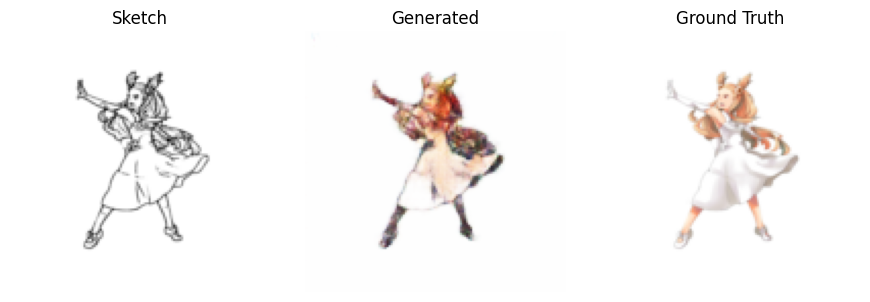

In [10]:
with torch.no_grad():
    sketches, colors, _ = next(iter(val_loader))
    sketches = sketches.to(device)
    fake = gen(sketches).cpu()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    axs[0].imshow(((sketches[0][0].cpu() + 1)/2).clamp(0,1), cmap="gray"); axs[0].set_title("Sketch"); axs[0].axis("off")
    axs[1].imshow(((fake[0].permute(1,2,0)+1)/2).clamp(0,1)); axs[1].set_title("Generated"); axs[1].axis("off")
    axs[2].imshow(((colors[0].permute(1,2,0).cpu()+1)/2).clamp(0,1)); axs[2].set_title("Ground Truth"); axs[2].axis("off")
    plt.tight_layout(); plt.show()


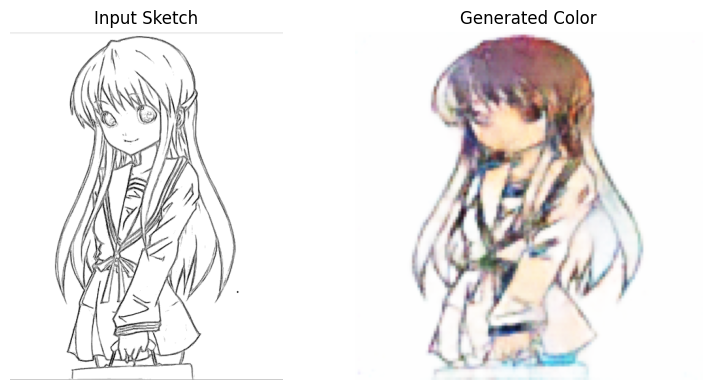

In [13]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

# --- Load trained generator ---
gen = UNetGenerator()
gen.load_state_dict(torch.load("checkpoints/gen_best.pth", map_location=device))
gen.to(device)
gen.eval()

# --- Path to your real sketch ---
sketch_path = r"E:\Group_52\Image\v2\Images\sketch_3.png"

# --- Preprocess sketch (grayscale + normalized to [-1,1]) ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

img = Image.open(sketch_path).convert("L")   # ensure grayscale
sketch = transform(img).unsqueeze(0).to(device)

# --- Generate colorized image ---
with torch.no_grad():
    fake_color = gen(sketch)[0].permute(1, 2, 0).cpu()
    fake_color = ((fake_color + 1) / 2).clamp(0, 1)

# --- Display result ---
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Input Sketch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_color)
plt.title("Generated Color")
plt.axis("off")

plt.tight_layout()
plt.show()


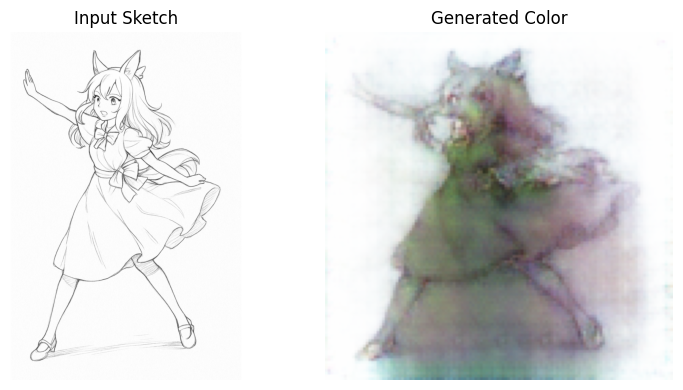

In [14]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

# --- Load trained generator ---
gen = UNetGenerator()
gen.load_state_dict(torch.load("checkpoints/gen_best.pth", map_location=device))
gen.to(device)
gen.eval()

# --- Path to your real sketch ---
sketch_path = r"E:\Group_52\Image\v2\Images\sketch_1.png"

# --- Preprocess sketch (grayscale + normalized to [-1,1]) ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

img = Image.open(sketch_path).convert("L")   # ensure grayscale
sketch = transform(img).unsqueeze(0).to(device)

# --- Generate colorized image ---
with torch.no_grad():
    fake_color = gen(sketch)[0].permute(1, 2, 0).cpu()
    fake_color = ((fake_color + 1) / 2).clamp(0, 1)

# --- Display result ---
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Input Sketch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_color)
plt.title("Generated Color")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import torch

# Save generator and discriminator weights
torch.save(gen.state_dict(), "generator_model.h5")
torch.save(disc.state_dict(), "discriminator_model.h5")

print("✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'")


✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'


In [7]:
gen = UNetGenerator()
disc = PatchDiscriminator()

gen.eval()

UNetGenerator(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
  )
  (middle): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128,

In [10]:
import torch

# Save generator and discriminator weights
torch.save(gen.state_dict(), "generator_model.h5")
torch.save(disc.state_dict(), "discriminator_model.h5")

print("✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'")


✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'


In [11]:
import torch

# Save generator and discriminator weights as .pth files
torch.save(gen.state_dict(), "generator_model.pth")
torch.save(disc.state_dict(), "discriminator_model.pth")

print("✅ Models saved as 'generator_model.pth' and 'discriminator_model.pth'")


✅ Models saved as 'generator_model.pth' and 'discriminator_model.pth'


In [17]:
!pip install scikit-image


  Using cached scikit_image-0.25.2-cp311-cp311-win_amd64.whl.metadata (14 kB)
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
Using cached scikit_image-0.25.2-cp311-cp311-win_amd64.whl (12.8 MB)
Using cached imageio-2.37.0-py3-none-any.whl (315 kB)

   ------------- -------------------------- 1/3 [imageio]
   ------------- -------------------------- 1/3 [imageio]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   ---------------------------------------- 3/3 [scikit-image]



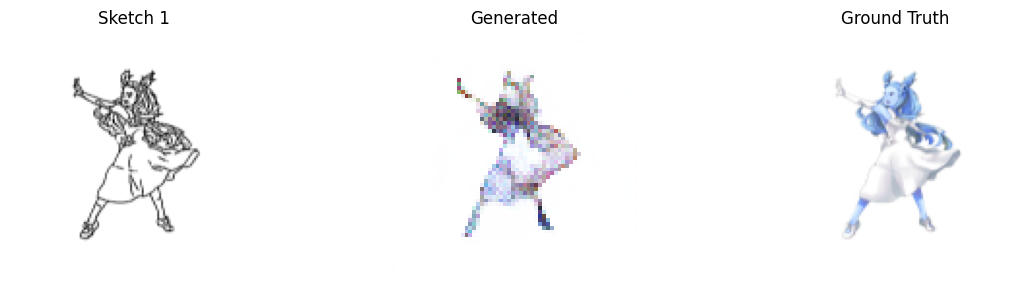

In [20]:
import torch
import matplotlib.pyplot as plt
import os

# Make sure the output folder exists
os.makedirs("validation_results", exist_ok=True)

# Set model to eval mode
gen.eval()

# Get one batch of validation data
sketches, colors, _ = next(iter(val_loader))
sketches, colors = sketches.to(device), colors.to(device)

# Generate outputs
with torch.no_grad():
    fake_colors = gen(sketches).cpu()

# Pick 5 samples max
num_samples = min(5, sketches.shape[0])

# Create plot
plt.figure(figsize=(12, num_samples * 3))

for i in range(num_samples):
    # 1️⃣ Sketch
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(sketches[i][0].cpu().detach().numpy() * 0.5 + 0.5, cmap='gray')
    plt.title(f"Sketch {i+1}")
    plt.axis("off")

    # 2️⃣ Generated color
    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(fake_colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Generated")
    plt.axis("off")

    # 3️⃣ Ground truth
    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.savefig("validation_results/val_preview_5samples.png", bbox_inches="tight")
plt.show()




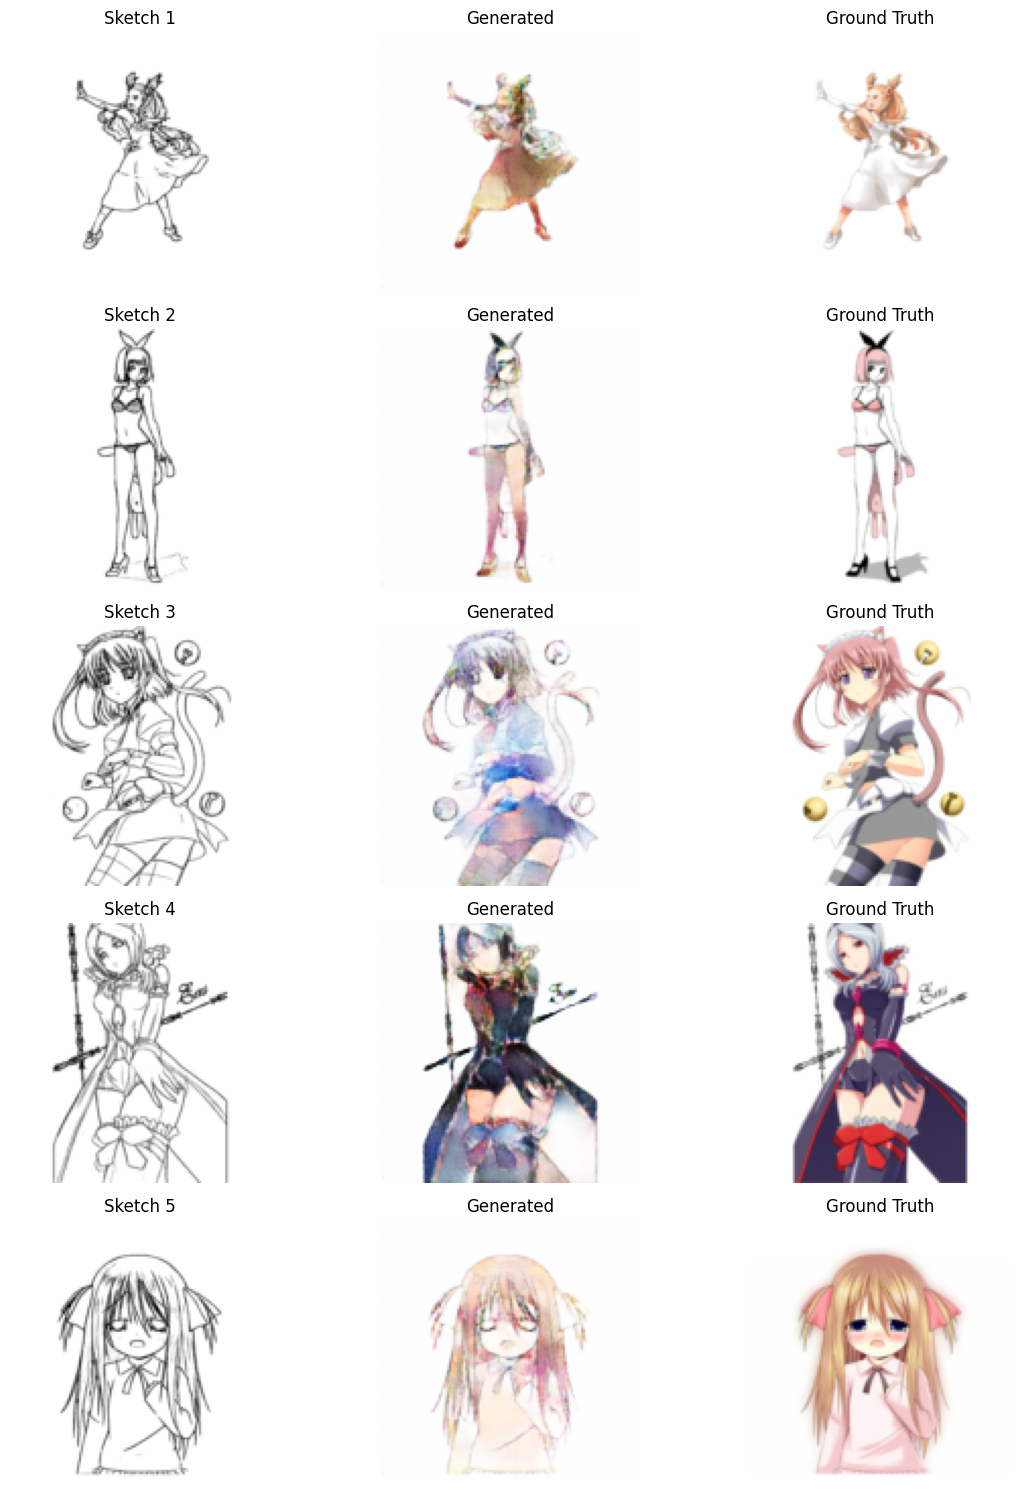

In [15]:
import torch
import matplotlib.pyplot as plt
import os

# Ensure output folder exists
os.makedirs("validation_results", exist_ok=True)

gen.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Collect 5 distinct samples
# ---------------------------
collected_samples = []
with torch.no_grad():
    for sketches, colors, _ in val_loader:
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)
        for i in range(sketches.shape[0]):
            collected_samples.append((
                sketches[i].cpu(),
                colors[i].cpu(),
                fake_colors[i].cpu()
            ))
            if len(collected_samples) >= 5:
                break
        if len(collected_samples) >= 5:
            break

# ---------------------------
# Plot the 5 samples
# ---------------------------
plt.figure(figsize=(12, 15))

for idx, (sketch, real, fake) in enumerate(collected_samples):
    # Sketch
    plt.subplot(5, 3, 3*idx + 1)
    plt.imshow(sketch[0].numpy() * 0.5 + 0.5, cmap='gray')
    plt.title(f"Sketch {idx+1}")
    plt.axis("off")

    # Generated
    plt.subplot(5, 3, 3*idx + 2)
    plt.imshow(fake.detach().permute(1, 2, 0).numpy() * 0.5 + 0.5)
    plt.title("Generated")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5, 3, 3*idx + 3)
    plt.imshow(real.detach().permute(1, 2, 0).numpy() * 0.5 + 0.5)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.savefig("validation_results/val_5samples_across_dataset.png", bbox_inches="tight")
plt.show()




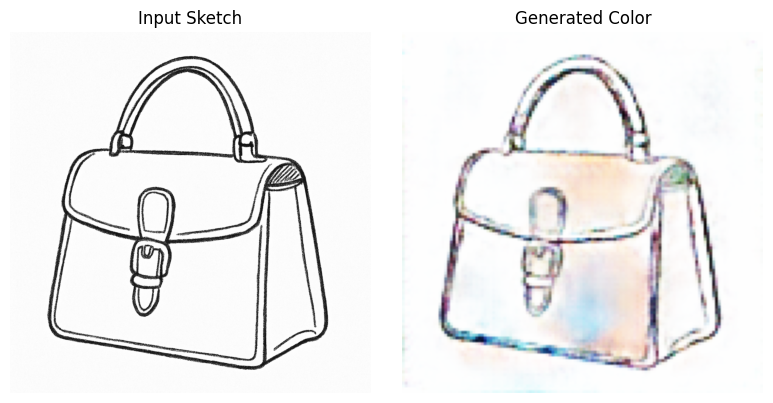

In [16]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Load and preprocess your sketch
# ----------------------------
def load_sketch(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # same normalization used during training
    ])
    img = Image.open(image_path).convert("L")  # grayscale
    return transform(img).unsqueeze(0)  # add batch dimension

# ----------------------------
# 2️⃣ Generate colorized image
# ----------------------------
def colorize_sketch(model, sketch_tensor, device="cuda"):
    model.eval()
    with torch.no_grad():
        sketch_tensor = sketch_tensor.to(device)
        fake_color = model(sketch_tensor)
        fake_color = fake_color.cpu().squeeze(0)  # remove batch dim
        fake_color = (fake_color * 0.5 + 0.5).clamp(0, 1)  # denormalize to [0,1]
    return fake_color

# ----------------------------
# 3️⃣ Visualize result
# ----------------------------
def show_colorization(sketch_path, model, device="cuda"):
    sketch_tensor = load_sketch(sketch_path)
    fake_color = colorize_sketch(model, sketch_tensor, device)

    # Display results
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sketch_path).convert("L"), cmap="gray")
    plt.title("Input Sketch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(fake_color.permute(1, 2, 0).numpy())
    plt.title("Generated Color")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4️⃣ Try with your own sketch
# ----------------------------
sketch_path = r"E:\Group_52\Image\v2\Images\sketch_2.png"  # 🔁 change to your uploaded file path
show_colorization(sketch_path, gen, device)
